# 10 — IID vs OOD Evaluation: Toggle OOD Experiments

Comprehensive comparison of IID and OOD performance across all holdout groups.
Uses the toggle_ood mechanism from the original CellOT paper: holdout cells are
split 50/50, one half for optional training (IID), one half always for evaluation.

**Key comparison**: Same evaluation cells in both modes. Only difference is whether
the model saw the other half of holdout cells during training.

Groups:
- T1: CD8, T2: CD8 + thymocyte, T3: All T cell subtypes, T4: CD4
- M1: Non-classical monocyte, M2: Non-classical + generic, M3: All monocyte subtypes, M4: Classical monocyte

Models: IMPACT (condition=species), IMPACT_CellOT (condition=cell_type_status), scGen (vector arithmetic baseline)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 50)

RESULTS_DIR = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results")

GROUPS = {
    't1': {'label': 'CD8', 'family': 'T cell'},
    't2': {'label': 'CD8 + thymocyte', 'family': 'T cell'},
    't3': {'label': 'All T cell subtypes', 'family': 'T cell'},
    't4': {'label': 'CD4', 'family': 'T cell'},
    'm1': {'label': 'Non-classical monocyte', 'family': 'Monocyte'},
    'm2': {'label': 'Non-classical + generic', 'family': 'Monocyte'},
    'm3': {'label': 'All monocyte subtypes', 'family': 'Monocyte'},
    'm4': {'label': 'Classical monocyte', 'family': 'Monocyte'},
}

MODES = ['ood', 'iid']
MODELS = {'impact': 'IMPACT', 'cellot': 'IMPACT_CellOT'}

print(f"Results dir: {RESULTS_DIR}")
print(f"Groups: {list(GROUPS.keys())}")
print("Setup complete.")

Results dir: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results
Groups: ['t1', 't2', 't3', 't4', 'm1', 'm2', 'm3', 'm4']
Setup complete.


## 1. Collect All Results

In [17]:
def parse_evals_csv(evals_path):
    """Read evals.csv, aggregate at max ncells, square r2 values."""
    df = pd.read_csv(evals_path)
    if len(df) <= 1:
        return None
    max_ncells = df['ncells'].max()
    sub = df[df['ncells'] == max_ncells]
    metrics = {}
    for metric_name in sub['metric'].unique():
        vals = sub[sub['metric'] == metric_name]['value'].dropna()
        if len(vals) > 0:
            val = vals.mean()
            if metric_name in ('r2-means', 'r2-stds', 'r2-pairwise_feat_corrs'):
                val = val ** 2
            metrics[metric_name] = val
    return metrics


all_results = []

for gk, ginfo in GROUPS.items():
    for mode in MODES:
        for model_dir, model_name in MODELS.items():
            tag = f"toggle_{gk}_{mode}"
            evals_path = RESULTS_DIR / tag / model_dir / 'evals_ood_latent_space' / 'evals.csv'
            
            if evals_path.exists():
                metrics = parse_evals_csv(evals_path)
                if metrics:
                    row = {
                        'group': gk,
                        'group_label': ginfo['label'],
                        'family': ginfo['family'],
                        'mode': mode,
                        'model': model_name,
                    }
                    for k, v in metrics.items():
                        row[k.replace('-', '_')] = v
                    all_results.append(row)
                    r2m = metrics.get('r2-means', float('nan'))
                    mmd = metrics.get('mmd', float('nan'))
                    print(f"  {tag}/{model_dir}: R²={r2m:.4f}, MMD={mmd:.6f}")
                else:
                    print(f"  {tag}/{model_dir}: empty evals.csv")
            else:
                print(f"  {tag}/{model_dir}: not found")

results_df = pd.DataFrame(all_results)
print(f"\nTotal results: {len(results_df)}")

  toggle_t1_ood/impact: R²=0.8407, MMD=0.022110
  toggle_t1_ood/cellot: R²=0.7118, MMD=0.032250
  toggle_t1_iid/impact: R²=0.8670, MMD=0.021868
  toggle_t1_iid/cellot: R²=0.9094, MMD=0.015870
  toggle_t2_ood/impact: R²=0.8290, MMD=0.020226
  toggle_t2_ood/cellot: R²=0.6806, MMD=0.052007
  toggle_t2_iid/impact: R²=0.8435, MMD=0.018274
  toggle_t2_iid/cellot: R²=0.9167, MMD=0.012288
  toggle_t3_ood/impact: R²=0.7966, MMD=0.023287
  toggle_t3_ood/cellot: R²=0.7277, MMD=0.040693
  toggle_t3_iid/impact: R²=0.8716, MMD=0.014596
  toggle_t3_iid/cellot: R²=0.8833, MMD=0.013035
  toggle_t4_ood/impact: R²=0.7721, MMD=0.049496
  toggle_t4_ood/cellot: R²=0.4138, MMD=0.079624
  toggle_t4_iid/impact: R²=0.7589, MMD=0.048978
  toggle_t4_iid/cellot: R²=0.7954, MMD=0.045297
  toggle_m1_ood/impact: R²=0.7310, MMD=0.035698
  toggle_m1_ood/cellot: R²=0.5946, MMD=0.055014
  toggle_m1_iid/impact: R²=0.7896, MMD=0.031727
  toggle_m1_iid/cellot: R²=0.9491, MMD=0.019202
  toggle_m2_ood/impact: R²=0.7512, MMD=0

## 1b. scGen Evaluation (Vector Arithmetic Baseline)

scGen was not evaluated via `evaluate.py` — it uses a different prediction mechanism
(vector arithmetic in latent space). We evaluate it inline by:
1. Loading the trained scGen model
2. Loading the holdout data with the same toggle_ood split
3. Computing the shift vector from training-split cells
4. Applying the shift to OOD source cells
5. Computing metrics on the predictions vs ground truth

In [18]:
import anndata
import torch
import torch.nn as nn
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import rbf_kernel

DATASET_DIR = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse")

HOLDOUT_IDS = {
    't1': ['CL:0000625'],
    't2': ['CL:0000625', 'CL:0000893'],
    't3': ['CL:0000624', 'CL:0000625', 'CL:0000893'],
    't4': ['CL:0000624'],
    'm1': ['CL:0000875'],
    'm2': ['CL:0000875', 'CL:0000576'],
    'm3': ['CL:0000875', 'CL:0000860', 'CL:0002393', 'CL:0000576'],
    'm4': ['CL:0000860'],
}

CT_COL = 'cell_type_ontology_term_id'


def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)
    return xx.mean() + yy.mean() - 2 * xy.mean()


def build_scgen_encoder(input_dim, latent_dim=50, hidden_units=(256, 256), dropout=0.1):
    """Reconstruct scGen encoder from architecture params (no cellot imports)."""
    layers = []
    prev_dim = input_dim
    for h in hidden_units[:-1]:
        layers.extend([nn.Linear(prev_dim, h), nn.ReLU(), nn.Dropout(dropout)])
        prev_dim = h
    layers.extend([nn.Linear(prev_dim, hidden_units[-1]), nn.ReLU(), nn.Dropout(dropout)])
    layers.append(nn.Linear(hidden_units[-1], latent_dim))
    return nn.Sequential(*layers)


def load_scgen_encoder(model_path, input_dim):
    """Load a trained scGen model and return just the encoder."""
    state = torch.load(model_path, map_location='cpu')
    encoder = build_scgen_encoder(input_dim)
    encoder_state = {k.replace('encoder_net.', ''): v
                     for k, v in state['model_state'].items()
                     if k.startswith('encoder_net.')}
    encoder.load_state_dict(encoder_state)
    encoder.eval()
    return encoder


def evaluate_scgen_toggle(group_key, mode):
    """Evaluate scGen on toggle_ood holdout cells using vector arithmetic."""
    tag = f"toggle_{group_key}_{mode}"
    scgen_dir = RESULTS_DIR / tag / "scgen"
    model_path = scgen_dir / "cache" / "model.pt"

    if not model_path.exists():
        return None

    data = anndata.read_h5ad(str(DATASET_DIR / f"toggle_{group_key}_holdout_v07.h5ad"))
    data.X = to_dense(data.X).astype(np.float32)

    encoder = load_scgen_encoder(model_path, data.n_vars)

    holdout_ids = HOLDOUT_IDS[group_key]
    is_holdout = data.obs[CT_COL].astype(str).isin(holdout_ids)
    holdout_idx = data.obs_names[is_holdout]
    trainobs, testobs = train_test_split(holdout_idx, random_state=0, test_size=0.5)

    eval_idx = testobs

    is_mouse = data.obs['condition'].astype(str) == 'mouse'
    is_human = data.obs['condition'].astype(str) == 'human'

    source_eval = data[data.obs_names.isin(eval_idx) & is_mouse]
    target_eval = data[data.obs_names.isin(eval_idx) & is_human]

    if mode == "ood":
        train_cells = data[~is_holdout]
    else:
        train_cells = data[~data.obs_names.isin(eval_idx)]

    train_mouse = train_cells[train_cells.obs['condition'].astype(str) == 'mouse']
    train_human = train_cells[train_cells.obs['condition'].astype(str) == 'human']

    with torch.no_grad():
        mouse_latent = encoder(torch.FloatTensor(train_mouse.X)).numpy()
        human_latent = encoder(torch.FloatTensor(train_human.X)).numpy()
        delta = human_latent.mean(0) - mouse_latent.mean(0)

        source_latent = encoder(torch.FloatTensor(source_eval.X)).numpy()
        pred_latent = source_latent + delta

        target_latent = encoder(torch.FloatTensor(target_eval.X)).numpy()

    treated = pd.DataFrame(target_latent)
    imputed = pd.DataFrame(pred_latent)

    mut, mui = treated.mean(0), imputed.mean(0)
    st, si = treated.std(0), imputed.std(0)

    r_means = pd.Series.corr(mut, mui)
    r_stds = pd.Series.corr(st, si)

    metrics = {
        'r2_means': r_means ** 2 if r_means == r_means else 0.0,
        'r2_stds': r_stds ** 2 if r_stds == r_stds else 0.0,
        'l2_means': np.linalg.norm(mut.values - mui.values),
    }

    gammas = np.logspace(1, -3, num=50)
    mmd_vals = [mmd_distance(treated.values, imputed.values, g) for g in gammas]
    metrics['mmd'] = np.mean(mmd_vals)

    return metrics


print("scGen evaluation function defined.")
print(f"Evaluating scGen for {len(HOLDOUT_IDS)} groups x 2 modes ...")

scgen_results = []
for gk in GROUPS:
    for mode in MODES:
        tag = f"toggle_{gk}_{mode}"
        metrics = evaluate_scgen_toggle(gk, mode)
        if metrics:
            row = {
                'group': gk,
                'group_label': GROUPS[gk]['label'],
                'family': GROUPS[gk]['family'],
                'mode': mode,
                'model': 'scGen',
                **metrics,
            }
            scgen_results.append(row)
            print(f"  {tag}/scgen: R²={metrics['r2_means']:.4f}, MMD={metrics['mmd']:.6f}")
        else:
            print(f"  {tag}/scgen: model not found")

scgen_df = pd.DataFrame(scgen_results)
results_df = pd.concat([results_df, scgen_df], ignore_index=True)
print(f"\nTotal results (with scGen): {len(results_df)}")

scGen evaluation function defined.
Evaluating scGen for 8 groups x 2 modes ...


  toggle_t1_ood/scgen: R²=0.6446, MMD=0.087178
  toggle_t1_iid/scgen: R²=0.7103, MMD=0.088268
  toggle_t2_ood/scgen: R²=0.5872, MMD=0.125414
  toggle_t2_iid/scgen: R²=0.6692, MMD=0.124694
  toggle_t3_ood/scgen: R²=0.5822, MMD=0.125574
  toggle_t3_iid/scgen: R²=0.5625, MMD=0.113434
  toggle_t4_ood/scgen: R²=0.3360, MMD=0.132443
  toggle_t4_iid/scgen: R²=0.3910, MMD=0.154085
  toggle_m1_ood/scgen: R²=0.4273, MMD=0.088925
  toggle_m1_iid/scgen: R²=0.4446, MMD=0.080721
  toggle_m2_ood/scgen: R²=0.4395, MMD=0.091578
  toggle_m2_iid/scgen: R²=0.4681, MMD=0.074897
  toggle_m3_ood/scgen: R²=0.3518, MMD=0.092512
  toggle_m3_iid/scgen: R²=0.6402, MMD=0.082288
  toggle_m4_ood/scgen: R²=0.4104, MMD=0.116933
  toggle_m4_iid/scgen: R²=0.4516, MMD=0.113478

Total results (with scGen): 48


## 2. Full Results Table

In [19]:
if len(results_df) > 0:
    show_cols = ['group', 'group_label', 'family', 'mode', 'model',
                 'r2_means', 'r2_stds', 'mmd']
    show_cols = [c for c in show_cols if c in results_df.columns]
    display(results_df[show_cols].sort_values(['family', 'group', 'mode', 'model']).round(4))

,group,group_label,family,mode,model,r2_means,r2_stds,mmd
19,m1,Non-classical monocyte,Monocyte,iid,CellOT,0.9491,0.9197,0.0192
18,m1,Non-classical monocyte,Monocyte,iid,IMPACT,0.7896,0.8958,0.0317
41,m1,Non-classical monocyte,Monocyte,iid,scGen,0.4446,0.8560,0.0807
17,m1,Non-classical monocyte,Monocyte,ood,CellOT,0.5946,0.8038,0.0550
16,m1,Non-classical monocyte,Monocyte,ood,IMPACT,0.7310,0.8581,0.0357
40,m1,Non-classical monocyte,Monocyte,ood,scGen,0.4273,0.8194,0.0889
23,m2,Non-classical + generic,Monocyte,iid,CellOT,0.9445,0.8982,0.0192
22,m2,Non-classical + generic,Monocyte,iid,IMPACT,0.8210,0.8725,0.0274
43,m2,Non-classical + generic,Monocyte,iid,scGen,0.4681,0.8200,0.0749
21,m2,Non-classical + generic,Monocyte,ood,CellOT,0.6798,0.5760,0.0901


## 3. IID vs OOD Comparison Table

Side-by-side comparison: for each group and model, show OOD and IID metrics
with the delta (IID - OOD). Positive delta in R² means IID is better (as expected).

In [20]:
if len(results_df) > 0:
    ood_df = results_df[results_df['mode'] == 'ood'].copy()
    iid_df = results_df[results_df['mode'] == 'iid'].copy()
    
    merge_keys = ['group', 'group_label', 'family', 'model']
    
    comparison = ood_df[merge_keys + ['r2_means', 'r2_stds', 'mmd']].merge(
        iid_df[merge_keys + ['r2_means', 'r2_stds', 'mmd']],
        on=merge_keys,
        suffixes=('_ood', '_iid'),
    )
    
    comparison['r2_means_delta'] = comparison['r2_means_iid'] - comparison['r2_means_ood']
    comparison['r2_stds_delta'] = comparison['r2_stds_iid'] - comparison['r2_stds_ood']
    comparison['mmd_delta'] = comparison['mmd_iid'] - comparison['mmd_ood']
    
    print("=" * 100)
    print("IID vs OOD Comparison (R² higher=better, MMD lower=better)")
    print("Positive R² delta = IID better. Negative MMD delta = IID better.")
    print("=" * 100)
    
    display_cols = ['group', 'group_label', 'model',
                    'r2_means_ood', 'r2_means_iid', 'r2_means_delta',
                    'mmd_ood', 'mmd_iid', 'mmd_delta']
    display_cols = [c for c in display_cols if c in comparison.columns]
    display(comparison[display_cols].sort_values(['group', 'model']).round(4))

IID vs OOD Comparison (R² higher=better, MMD lower=better)
Positive R² delta = IID better. Negative MMD delta = IID better.


,group,group_label,model,r2_means_ood,r2_means_iid,r2_means_delta,mmd_ood,mmd_iid,mmd_delta
9,m1,Non-classical monocyte,CellOT,0.5946,0.9491,0.3545,0.0550,0.0192,-0.0358
8,m1,Non-classical monocyte,IMPACT,0.7310,0.7896,0.0586,0.0357,0.0317,-0.0040
20,m1,Non-classical monocyte,scGen,0.4273,0.4446,0.0173,0.0889,0.0807,-0.0082
11,m2,Non-classical + generic,CellOT,0.6798,0.9445,0.2647,0.0901,0.0192,-0.0708
10,m2,Non-classical + generic,IMPACT,0.7512,0.8210,0.0698,0.0310,0.0274,-0.0036
21,m2,Non-classical + generic,scGen,0.4395,0.4681,0.0286,0.0916,0.0749,-0.0167
13,m3,All monocyte subtypes,CellOT,0.4581,0.9715,0.5134,0.0971,0.0077,-0.0893
12,m3,All monocyte subtypes,IMPACT,0.6406,0.8236,0.1830,0.0317,0.0243,-0.0074
22,m3,All monocyte subtypes,scGen,0.3518,0.6402,0.2884,0.0925,0.0823,-0.0102
15,m4,Classical monocyte,CellOT,0.4935,0.7749,0.2814,0.1109,0.0579,-0.0530


## 4. Presentation Focus: T1 (CD8) and M1 (Non-classical Monocyte)

These are the key experiments for the presentation (from March 30 meeting).

In [21]:
if len(results_df) > 0:
    for gk, title in [('t1', 'T1: CD8 Holdout'), ('m1', 'M1: Non-classical Monocyte Holdout')]:
        subset = comparison[comparison['group'] == gk]
        if len(subset) > 0:
            print(f"\n{'=' * 70}")
            print(f"  {title}")
            print(f"{'=' * 70}")
            for _, row in subset.iterrows():
                print(f"\n  {row['model']}:")
                print(f"    R² means:  OOD={row['r2_means_ood']:.4f}  IID={row['r2_means_iid']:.4f}  Δ={row['r2_means_delta']:+.4f}")
                if 'mmd_ood' in row and not pd.isna(row['mmd_ood']):
                    print(f"    MMD:       OOD={row['mmd_ood']:.6f}  IID={row['mmd_iid']:.6f}  Δ={row['mmd_delta']:+.6f}")


  T1: CD8 Holdout

  IMPACT:
    R² means:  OOD=0.8407  IID=0.8670  Δ=+0.0263
    MMD:       OOD=0.022110  IID=0.021868  Δ=-0.000242

  CellOT:
    R² means:  OOD=0.7118  IID=0.9094  Δ=+0.1976
    MMD:       OOD=0.032250  IID=0.015870  Δ=-0.016379

  scGen:
    R² means:  OOD=0.6446  IID=0.7103  Δ=+0.0657
    MMD:       OOD=0.087178  IID=0.088268  Δ=+0.001089

  M1: Non-classical Monocyte Holdout

  IMPACT:
    R² means:  OOD=0.7310  IID=0.7896  Δ=+0.0586
    MMD:       OOD=0.035698  IID=0.031727  Δ=-0.003970

  CellOT:
    R² means:  OOD=0.5946  IID=0.9491  Δ=+0.3545
    MMD:       OOD=0.055014  IID=0.019202  Δ=-0.035811

  scGen:
    R² means:  OOD=0.4273  IID=0.4446  Δ=+0.0173
    MMD:       OOD=0.088925  IID=0.080721  Δ=-0.008204


## 5. Visualization: IID vs OOD Bar Charts

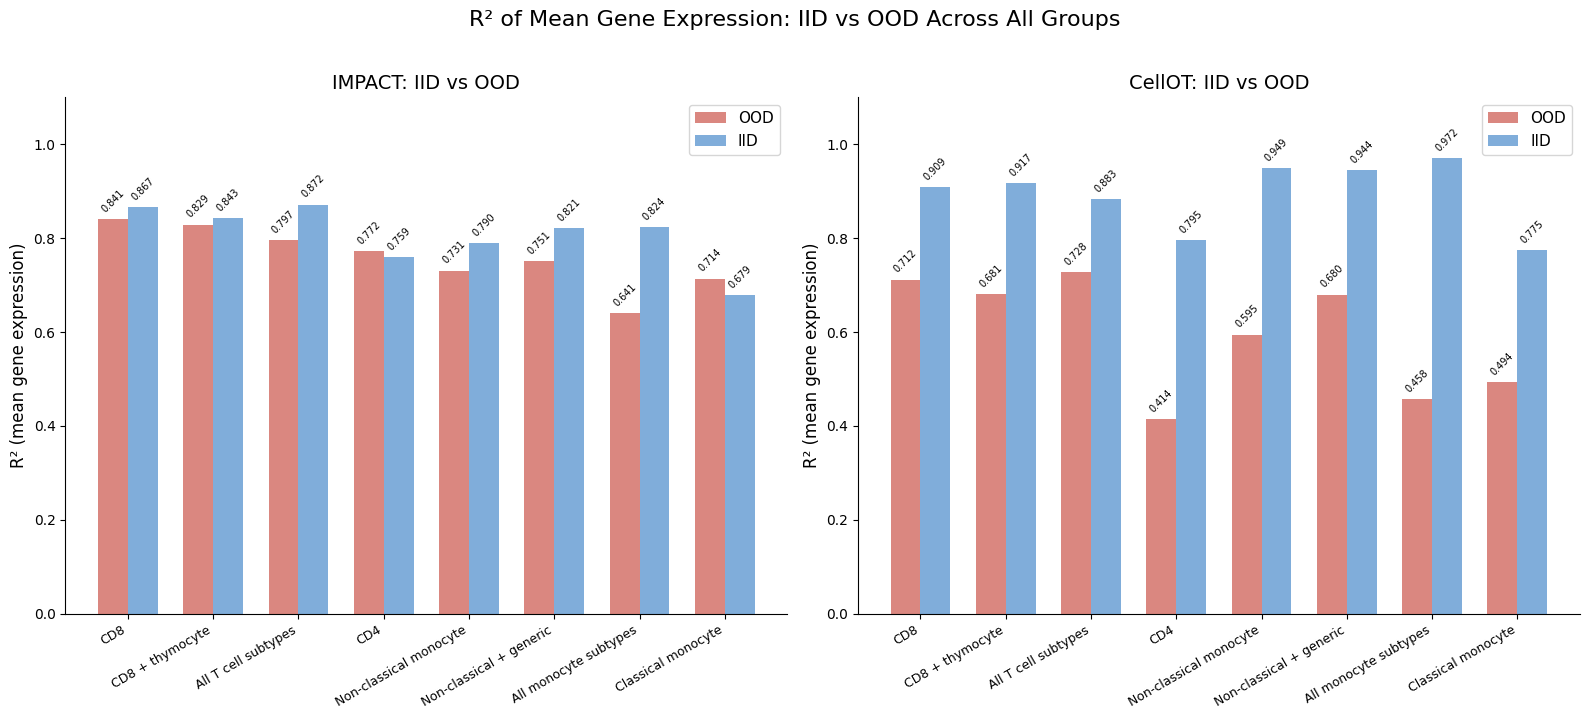

In [22]:
if len(results_df) > 0 and 'r2_means' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    group_order = ['t1', 't2', 't3', 't4', 'm1', 'm2', 'm3', 'm4']
    group_labels = [GROUPS[g]['label'] for g in group_order]
    
    for ax_idx, (model_name, ax) in enumerate(zip(['IMPACT', 'IMPACT_CellOT'], axes)):
        model_data = results_df[results_df['model'] == model_name]
        
        x = np.arange(len(group_order))
        width = 0.35
        
        ood_vals = []
        iid_vals = []
        for gk in group_order:
            ood_row = model_data[(model_data['group'] == gk) & (model_data['mode'] == 'ood')]
            iid_row = model_data[(model_data['group'] == gk) & (model_data['mode'] == 'iid')]
            ood_vals.append(ood_row['r2_means'].values[0] if len(ood_row) > 0 else 0)
            iid_vals.append(iid_row['r2_means'].values[0] if len(iid_row) > 0 else 0)
        
        bars_ood = ax.bar(x - width/2, ood_vals, width, label='OOD', color='#D4726A', alpha=0.85)
        bars_iid = ax.bar(x + width/2, iid_vals, width, label='IID', color='#6A9FD4', alpha=0.85)
        
        for bar, val in zip(bars_ood, ood_vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                        ha='center', va='bottom', fontsize=7, rotation=45)
        for bar, val in zip(bars_iid, iid_vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                        ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.set_ylabel('R² (mean gene expression)', fontsize=12)
        ax.set_title(f'{model_name}: IID vs OOD', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(group_labels, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.legend(fontsize=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.suptitle('R² of Mean Gene Expression: IID vs OOD Across All Groups', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

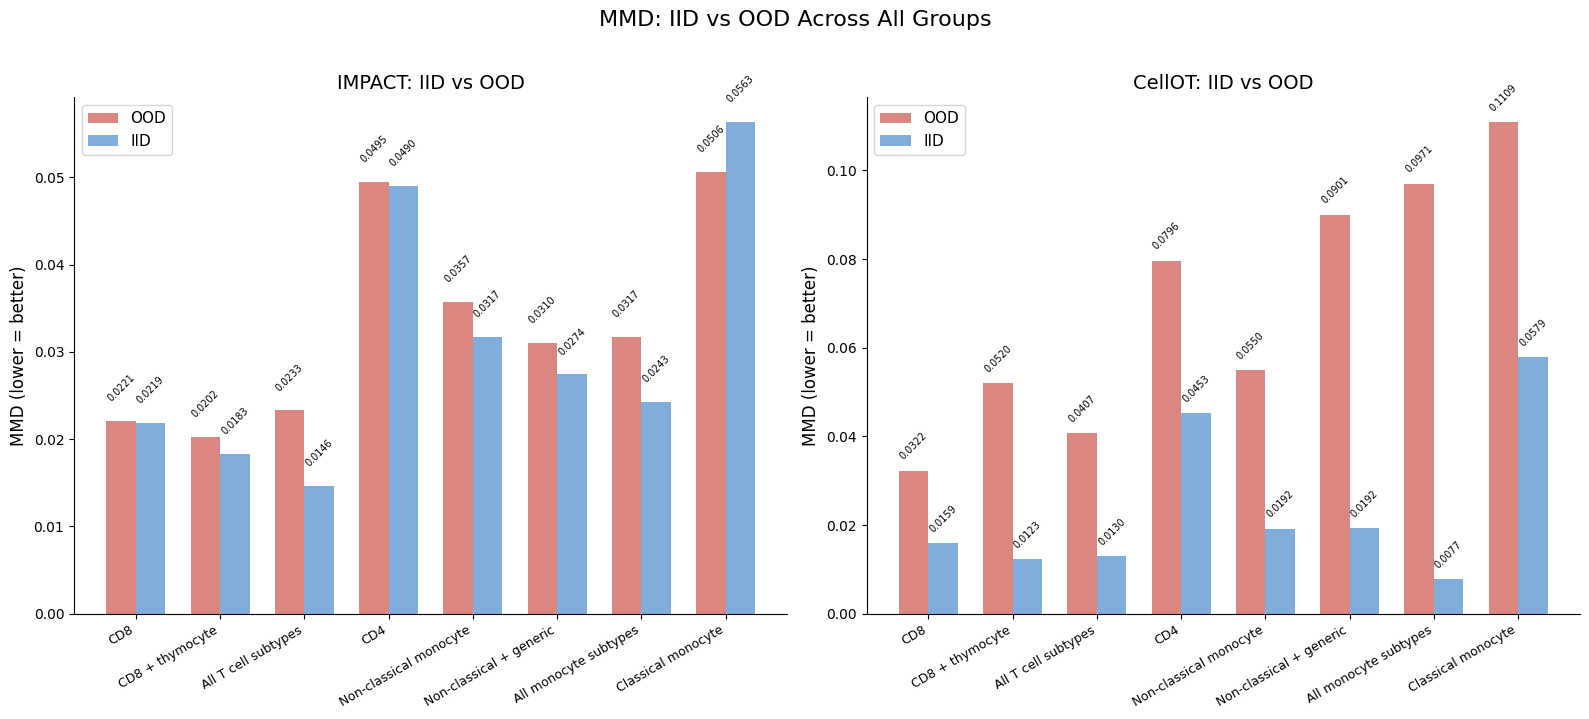

In [23]:
if len(results_df) > 0 and 'mmd' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for ax_idx, (model_name, ax) in enumerate(zip(['IMPACT', 'IMPACT_CellOT'], axes)):
        model_data = results_df[results_df['model'] == model_name]
        
        x = np.arange(len(group_order))
        width = 0.35
        
        ood_vals = []
        iid_vals = []
        for gk in group_order:
            ood_row = model_data[(model_data['group'] == gk) & (model_data['mode'] == 'ood')]
            iid_row = model_data[(model_data['group'] == gk) & (model_data['mode'] == 'iid')]
            ood_vals.append(ood_row['mmd'].values[0] if len(ood_row) > 0 and 'mmd' in ood_row.columns else 0)
            iid_vals.append(iid_row['mmd'].values[0] if len(iid_row) > 0 and 'mmd' in iid_row.columns else 0)
        
        bars_ood = ax.bar(x - width/2, ood_vals, width, label='OOD', color='#D4726A', alpha=0.85)
        bars_iid = ax.bar(x + width/2, iid_vals, width, label='IID', color='#6A9FD4', alpha=0.85)
        
        for bar, val in zip(bars_ood, ood_vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
                        ha='center', va='bottom', fontsize=7, rotation=45)
        for bar, val in zip(bars_iid, iid_vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
                        ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.set_ylabel('MMD (lower = better)', fontsize=12)
        ax.set_title(f'{model_name}: IID vs OOD', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(group_labels, rotation=30, ha='right', fontsize=9)
        ax.legend(fontsize=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.suptitle('MMD: IID vs OOD Across All Groups', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. T cell vs Monocyte Family Comparison

Compare the IID-OOD gap across T cell and monocyte families.

In [24]:
if len(results_df) > 0 and len(comparison) > 0:
    comparison_with_family = comparison.copy()
    comparison_with_family['family'] = comparison_with_family['group'].map(
        lambda g: GROUPS[g]['family']
    )
    
    print("=" * 70)
    print("Average IID-OOD Delta by Cell Family and Model")
    print("=" * 70)
    
    family_summary = comparison_with_family.groupby(['family', 'model']).agg({
        'r2_means_delta': 'mean',
        'mmd_delta': 'mean',
    }).round(4)
    
    display(family_summary)
    
    print("\nInterpretation:")
    print("  Positive R² delta = IID outperforms OOD (expected)")
    print("  Negative MMD delta = IID distribution is closer to ground truth (expected)")

Average IID-OOD Delta by Cell Family and Model


r2_means_delta  mmd_delta
family   model                            
Monocyte CellOT          0.3535    -0.0622
         IMPACT          0.0690    -0.0023
         scGen           0.0939    -0.0096
T cell   CellOT          0.2428    -0.0295
         IMPACT          0.0256    -0.0029
         scGen           0.0458     0.0025


Interpretation:
  Positive R² delta = IID outperforms OOD (expected)
  Negative MMD delta = IID distribution is closer to ground truth (expected)


## 7. Export Results

In [25]:
if len(results_df) > 0:
    out_dir = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis")
    
    results_df.round(6).to_csv(out_dir / 'toggle_ood_all_results.csv', index=False)
    print(f"Saved: {out_dir / 'toggle_ood_all_results.csv'}")
    
    if len(comparison) > 0:
        comparison.round(6).to_csv(out_dir / 'toggle_ood_iid_vs_ood_comparison.csv', index=False)
        print(f"Saved: {out_dir / 'toggle_ood_iid_vs_ood_comparison.csv'}")

Saved: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/toggle_ood_all_results.csv
Saved: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/toggle_ood_iid_vs_ood_comparison.csv
